In [ ]:
import json
import glob
import pandas as pd

files = glob.glob("../data/raw//.jsonl")

rows = []

for file in files:
    with open(file) as f:
        for line in f:
            rows.append(json.loads(line))

df = pd.DataFrame(rows)
df.head()

,id,title,abstract,authors,categories,primary_category,published,year,month,pdf
0,http://arxiv.org/abs/2201.00084v1,Performance Comparison of Deep Learning Archit...,Endoscopic images typically contain several ar...,"[Taira Watanabe, Kensuke Tanioka, Satoru Hiwa,...","[eess.IV, cs.CV, cs.LG]",cs.LG,2022-01-01T01:04:51Z,2022,1,https://arxiv.org/pdf/2201.00084v1
1,http://arxiv.org/abs/2201.00087v6,Persistent Homological State-Space Estimation ...,"We introduce an innovative, data-driven topolo...","[Moo K. Chung, Shih-Gu Huang, Ian C. Carroll, ...","[math.AT, cs.LG, q-bio.NC]",cs.LG,2022-01-01T01:39:05Z,2022,1,https://arxiv.org/pdf/2201.00087v6
2,http://arxiv.org/abs/2201.00093v1,Distributed Evolution Strategies Using TPUs fo...,Meta-learning traditionally relies on backprop...,"[Alex Sheng, Derek He]","[cs.NE, cs.AI, cs.LG]",cs.LG,2022-01-01T02:14:02Z,2022,1,https://arxiv.org/pdf/2201.00093v1
3,http://arxiv.org/abs/2201.00111v1,Role of Data Augmentation Strategies in Knowle...,Deep neural networks are parametrized by sever...,"[Eun Som Jeon, Anirudh Som, Ankita Shukla, Kri...","[cs.LG, cs.HC, eess.SP]",cs.LG,2022-01-01T04:40:14Z,2022,1,https://arxiv.org/pdf/2201.00111v1
4,http://arxiv.org/abs/2201.00115v1,Toward the Analysis of Graph Neural Networks,Graph Neural Networks (GNNs) have recently eme...,"[Thanh-Dat Nguyen, Thanh Le-Cong, ThanhVu H. N...","[cs.SE, cs.LG]",cs.LG,2022-01-01T04:59:49Z,2022,1,https://arxiv.org/pdf/2201.00115v1


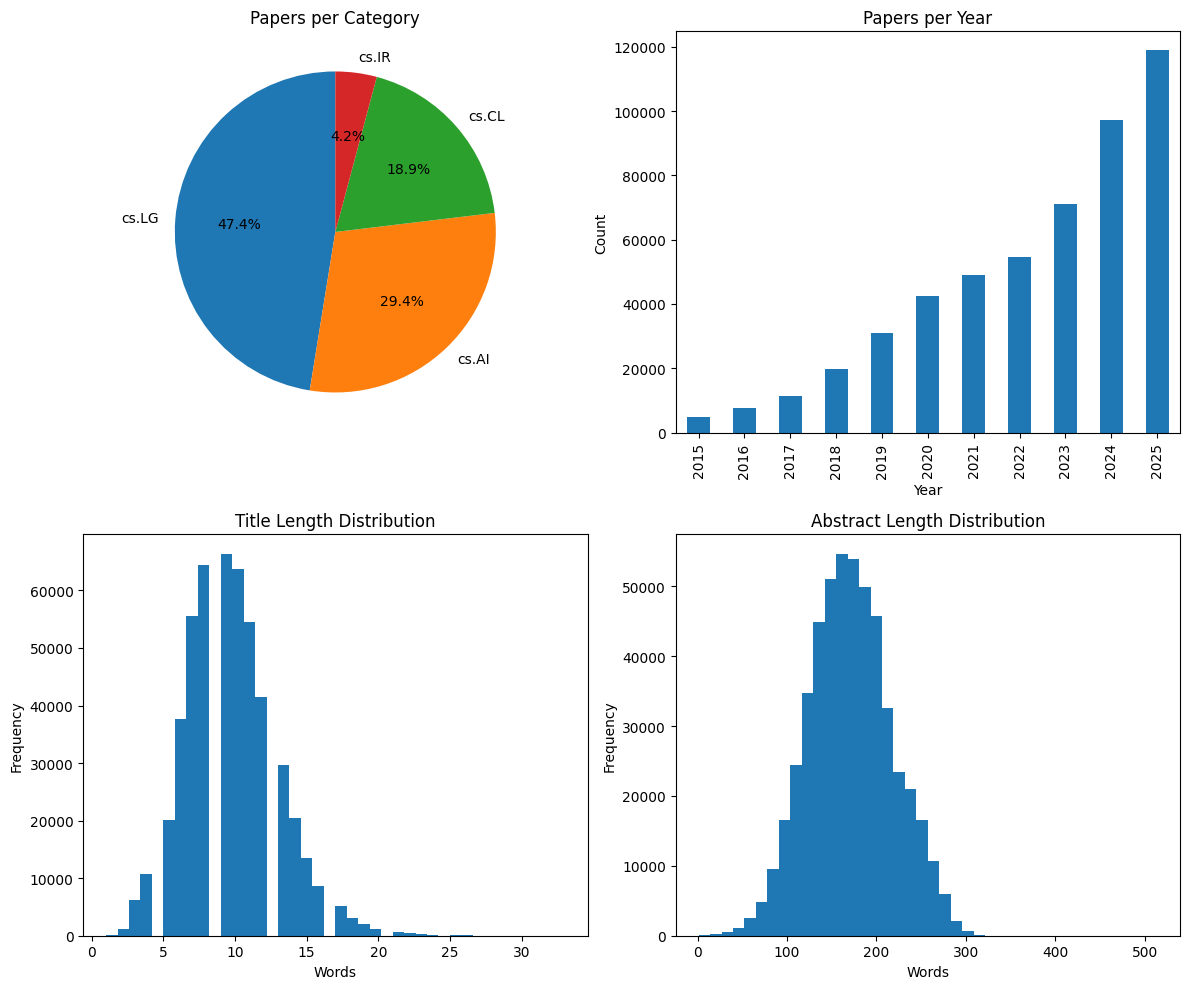

In [19]:
import matplotlib.pyplot as plt

df["title_len"] = df["title"].str.split().str.len()
df["abstract_len"] = df["abstract"].str.split().str.len()

fig, ax = plt.subplots(2, 2, figsize=(12, 10))

df["primary_category"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    ax=ax[0,0]
)
ax[0,0].set_title("Papers per Category")
ax[0,0].set_ylabel("")

df["year"].value_counts().sort_index().plot(
    kind="bar",
    ax=ax[0,1]
)
ax[0,1].set_title("Papers per Year")
ax[0,1].set_xlabel("Year")
ax[0,1].set_ylabel("Count")

ax[1,0].hist(df["title_len"], bins=40)
ax[1,0].set_title("Title Length Distribution")
ax[1,0].set_xlabel("Words")
ax[1,0].set_ylabel("Frequency")

ax[1,1].hist(df["abstract_len"], bins=40)
ax[1,1].set_title("Abstract Length Distribution")
ax[1,1].set_xlabel("Words")
ax[1,1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

Tập dữ liệu bao gồm hơn 500.000 bài báo khoa học thuộc các lĩnh vực khác nhau của khoa học máy tính. Trong đó, Machine Learning (cs.LG) chiếm tỷ lệ lớn nhất (~47%), tiếp theo là Artificial Intelligence (cs.AI) (~29%), Computational Linguistics (cs.CL) (~19%) và Information Retrieval (cs.IR) (~4%). Điều này phản ánh xu hướng nghiên cứu hiện nay khi các phương pháp học máy, đặc biệt là học sâu, đang đóng vai trò trung tâm trong nhiều lĩnh vực của trí tuệ nhân tạo và xử lý ngôn ngữ tự nhiên.

Số lượng bài báo cũng tăng đều theo từng năm trong giai đoạn 2015–2025, cho thấy sự phát triển nhanh chóng của các lĩnh vực nghiên cứu này.

Về đặc điểm văn bản, độ dài của các bài báo chủ yếu nằm trong khoảng 5–20 từ, với giá trị phổ biến nhất khoảng 10 từ. Trong khi đó, phần tóm tắt (abstract) thường có độ dài khoảng 100–300 từ, với đỉnh phân bố xung quanh 200 từ. Điều này cho thấy các bài báo thường cung cấp lượng thông tin vừa đủ trong phần abstract để mô tả nội dung nghiên cứu, giúp hỗ trợ hiệu quả cho các hệ thống truy xuất thông tin và các mô hình xử lý ngôn ngữ tự nhiên.


Có tất cả 282254 từ


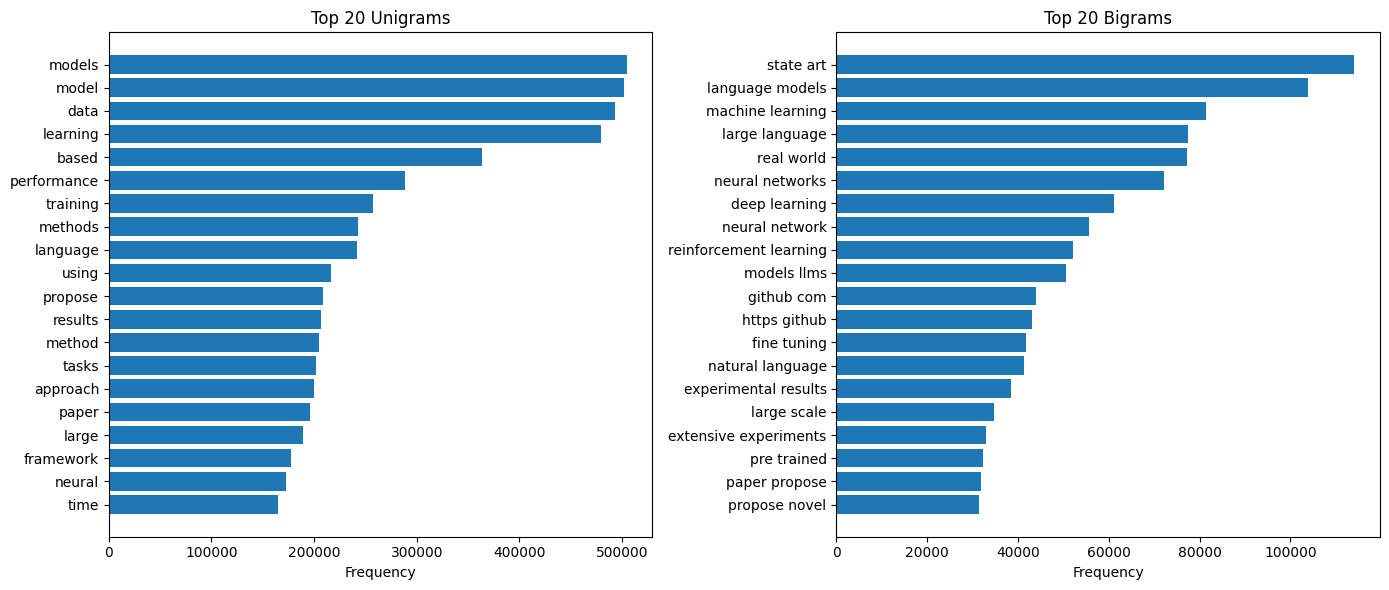

In [40]:
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(14,6))

vectorizer1 = CountVectorizer(stop_words="english", ngram_range=(1,1))
X1 = vectorizer1.fit_transform(df["abstract"])
print(f"Có tất cả {len(vectorizer1.get_feature_names_out())} từ")

words1 = vectorizer1.get_feature_names_out()
counts1 = X1.sum(axis=0).A1

freq1 = pd.DataFrame({
    "word": words1,
    "count": counts1
})

top20_1 = freq1.sort_values(by="count", ascending=False).head(20)

axes[0].barh(top20_1["word"], top20_1["count"])
axes[0].set_title("Top 20 Unigrams")
axes[0].invert_yaxis()
axes[0].set_xlabel("Frequency")


vectorizer2 = CountVectorizer(stop_words="english", ngram_range=(2,2))
X2 = vectorizer2.fit_transform(df["abstract"])

words2 = vectorizer2.get_feature_names_out()
counts2 = X2.sum(axis=0).A1

freq2 = pd.DataFrame({
    "word": words2,
    "count": counts2
})

top20_2 = freq2.sort_values(by="count", ascending=False).head(20)

axes[1].barh(top20_2["word"], top20_2["count"])
axes[1].set_title("Top 20 Bigrams")
axes[1].invert_yaxis()
axes[1].set_xlabel("Frequency")

plt.tight_layout()
plt.show()

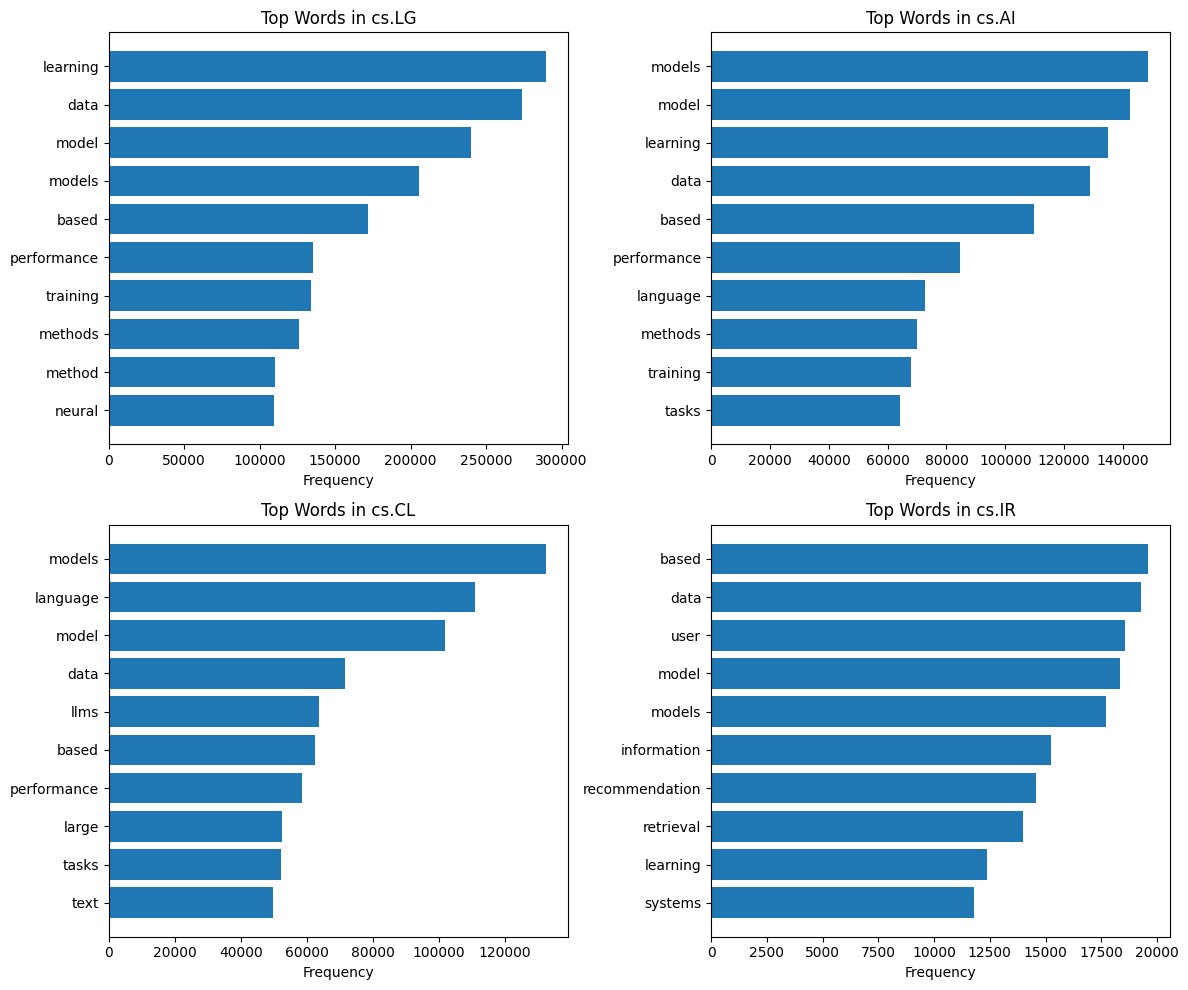

In [32]:
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

categories = ["cs.LG", "cs.AI", "cs.CL", "cs.IR"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, cat in enumerate(categories):

    subset = df[df["primary_category"] == cat]

    vectorizer = CountVectorizer(stop_words="english")
    X = vectorizer.fit_transform(subset["abstract"])

    words = vectorizer.get_feature_names_out()
    counts = X.sum(axis=0).A1

    freq_df = pd.DataFrame({
        "word": words,
        "count": counts
    })

    top10 = freq_df.sort_values(by="count", ascending=False).head(10)

    ax = axes[i]
    ax.barh(top10["word"], top10["count"])
    ax.set_title(f"Top Words in {cat}")
    ax.invert_yaxis()
    ax.set_xlabel("Frequency")

plt.tight_layout()
plt.show()

Đối với cs.LG, các từ xuất hiện nhiều thường liên quan đến học máy và dữ liệu như data, learning, performance.
Đối với cs.AI, các từ đặc trưng chủ yếu gắn với mô hình và quá trình huấn luyện như model, training, learning.
Trong cs.CL, các từ phổ biến liên quan đến xử lý ngôn ngữ tự nhiên như language, text, translation.
Trong khi đó, cs.IR thường xuất hiện các từ liên quan đến hệ thống thông tin và người dùng như user, information, recommendation.

Nhìn chung, mỗi lĩnh vực có các từ đặc trưng với tần suất cao, tuy nhiên phần lớn các từ phổ biến đều xoay quanh các khía cạnh cốt lõi của trí tuệ nhân tạo và học máy như mô hình, dữ liệu, quá trình học và đánh giá hệ thống. Các từ như models, performance, data, user và training phản ánh các thành phần quan trọng trong việc xây dựng và huấn luyện các hệ thống học máy.

Ngoài các từ đơn, việc phân tích các cụm hai từ cũng cho thấy nhiều cụm xuất hiện thường xuyên như machine learning, neural networks, deep learning, language models và reinforcement learning. Một số cụm khác như large language, fine tuning và pre trained phản ánh xu hướng nghiên cứu gần đây về các mô hình ngôn ngữ lớn và kỹ thuật tinh chỉnh mô hình. Các cụm như state of the art, experimental results và large scale thường xuất hiện trong phần mô tả đánh giá và thực nghiệm của các bài báo.